In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import random
import math

In [3]:
#Convierte request por minuto a milisegundos entre request
def get_millis_between_requests(throughput_rpm):
    return round(60000/throughput_rpm)

Metodo para calcular la probabilidad de expiracion, como input toma el age del objeto (ms) y el ttl (ms).
Retorna un float con la probabilidad de que el objeto tenga que ser considerado expirado.

In [4]:
def get_expiration_probability(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return invzone

Para todos los calculos voy a considerar el ttl en 200 segundos (200000 ms).

Grafico la probabilidad de expiracion en funcion del age

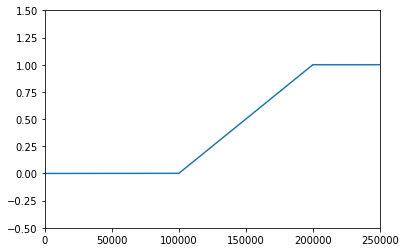

In [5]:
age=np.arange(0., 250000., 1)
proba=[get_expiration_probability(x,200000) for x in age]
plt.plot(age,proba)
plt.axis([0, 250000, -0.5, 1.5])
plt.show()

Cantidad de gets de cache que son considerados expirados expirados, segun distintos throughput. Siempre se considera constante la distancia entre request.


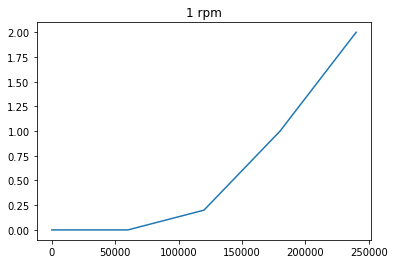

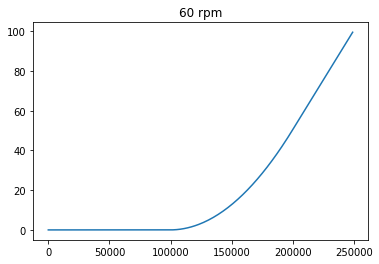

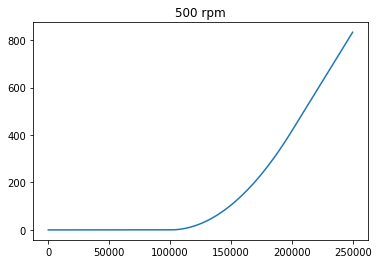

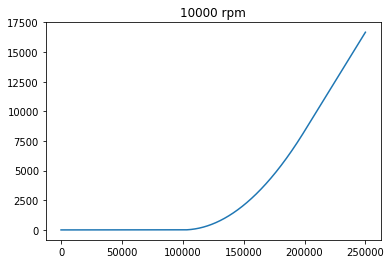

In [6]:
def print_plot_miss_by_rpm(rpm):
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    acc=[]
    accum=0
    for k in age:
        p=get_expiration_probability(k,200000)
        accum=accum+p
        acc.append(accum)

    plt.plot(age,acc)
    plt.title("%d rpm" % rpm)
    plt.show()

print_plot_miss_by_rpm(1)
print_plot_miss_by_rpm(60)
print_plot_miss_by_rpm(500)
print_plot_miss_by_rpm(10000)


## Curva de probabilidad de que algun get sea considerado miss en el tiempo
Aqui se considera la probabilidad de que al menos 1 get sea considerado miss. Esto es equivalente a 1-probabilidad de que ninguno.   
Lo interesante es ver como el escalon se mueve adelante en el tiempo a medida que aumentan el throughput

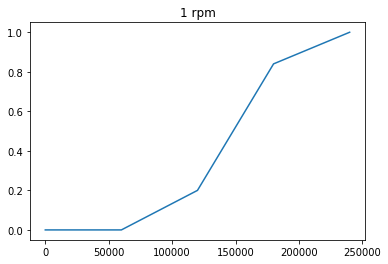

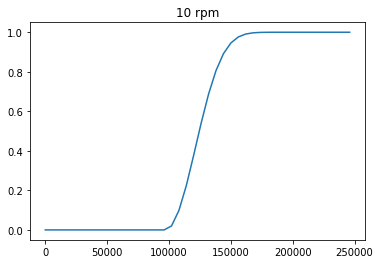

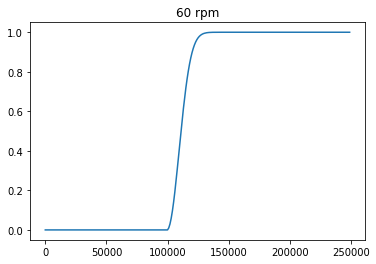

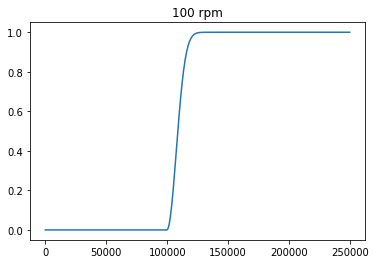

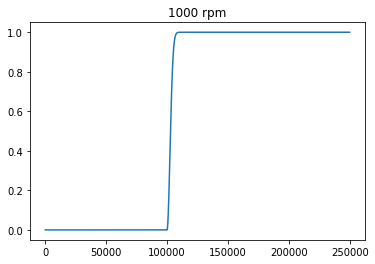

In [7]:
def probability_some_miss_by_time(rpm):
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    acc=[None]*250000
    none=1
    for k in age:
        p=get_expiration_probability(k,200000)
        q=1-p
        none=none*q
        acc[int(round(k))]=(1-none)
        
    prev=0
    for idx, val in enumerate(acc):
        if val is None:
            acc[idx]=prev
        else:
            prev=acc[idx]
    return acc
    
def print_plot_some_miss_by_rpm(rpm):
    miss_prob=probability_some_miss_by_time(rpm)
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    acc=[]
    for k in age:
        p=miss_prob[int(round(k))]
        acc.append(p)

    plt.plot(age,acc)
    plt.title("%d rpm" % rpm)
    plt.show()

print_plot_some_miss_by_rpm(1)
print_plot_some_miss_by_rpm(10)
print_plot_some_miss_by_rpm(60)
print_plot_some_miss_by_rpm(100)
print_plot_some_miss_by_rpm(1000)

# Curva probabilidad individual de Miss considerando regeneración
Aqui se indica la probabilidad de miss para cada get individual, considerando que no haya sido regenerado en el pasado y considerando que el tiempo de regeneracion es de por ejemplo 1000ms

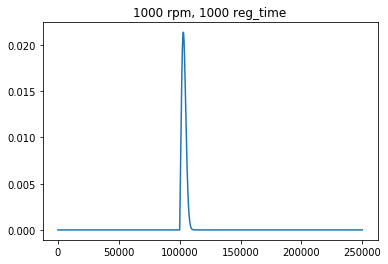

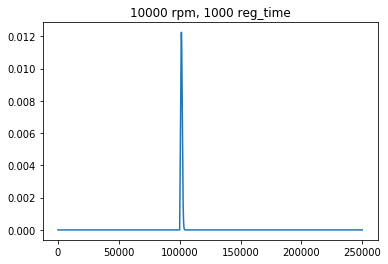

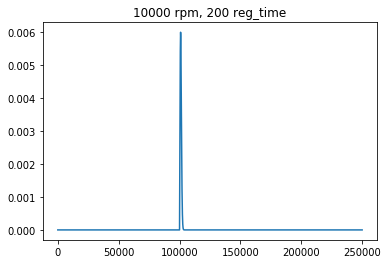

In [8]:
def print_plot_proba_miss_by_rpm_with_regeneration(rpm,regeneration_time):
    miss_prob=probability_some_miss_by_time(rpm)
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    acc=[]
    accum=0
    for k in age:
        p=get_expiration_probability(k,200000)
        psomeprevmiss=miss_prob[int(round(k-regeneration_time))]
        
        pefectivemiss=p* (1-psomeprevmiss)
        acc.append(pefectivemiss)

    plt.plot(age,acc)
    plt.title("%d rpm, %d reg_time" % (rpm,regeneration_time))
    plt.show()

print_plot_proba_miss_by_rpm_with_regeneration(1000,1000)
print_plot_proba_miss_by_rpm_with_regeneration(10000,1000)
print_plot_proba_miss_by_rpm_with_regeneration(10000,200)

# Curva acumulado cantidad de Miss considerando regeneracion
Ahora, asumiendo un tiempo de regeneracion del cache demora un tiempo cualquiera, ej 1000 ms.   
La curva de la cantidad de miss cambia ya que al haber terminado de regenerar ya es considerado un hit porque el age pasa a cero.  
EL cambio es que la probabilidad de haber expirado depende de la probabilidad de que no se haya regenerado. Siendo proba de expirado= proba_propia * (1-proba_regenerado).   
Siendo proba regenerado, la probabilidad de que alguno haya dado miss hace mas de 1000 ms.

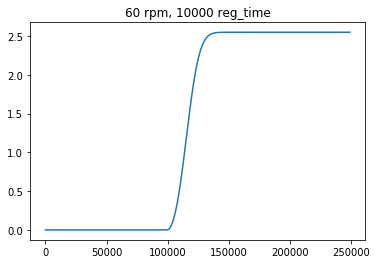

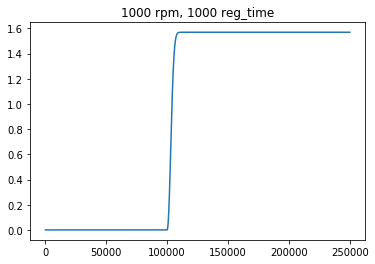

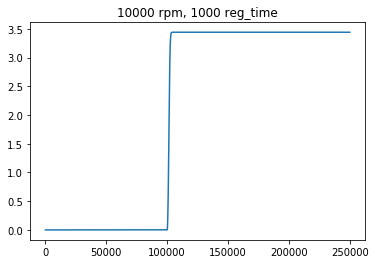

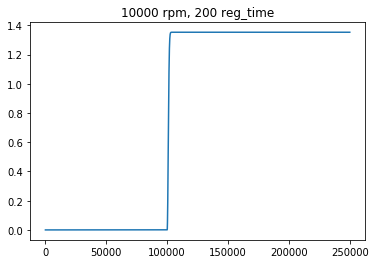

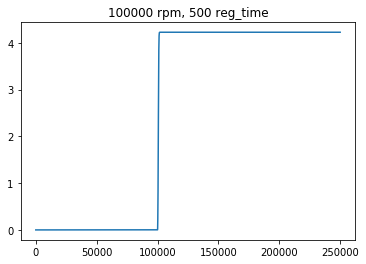

In [9]:
def print_plot_miss_count_by_rpm_with_regeneration(rpm,regeneration_time):
    miss_prob=probability_some_miss_by_time(rpm)
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    acc=[]
    accum=0
    for k in age:
        p=get_expiration_probability(k,200000)
        psomeprevmiss=miss_prob[int(round(k-regeneration_time))]
        
        pefectivemiss=p* (1-psomeprevmiss)
        accum=accum+pefectivemiss
        acc.append(accum)

    plt.plot(age,acc)
    plt.title("%d rpm, %d reg_time" % (rpm,regeneration_time))
    plt.show()

print_plot_miss_count_by_rpm_with_regeneration(60,10000)
print_plot_miss_count_by_rpm_with_regeneration(1000,1000)
print_plot_miss_count_by_rpm_with_regeneration(10000,1000)
print_plot_miss_count_by_rpm_with_regeneration(10000,200)
print_plot_miss_count_by_rpm_with_regeneration(100000,500)

# Verificacion acumulado de misses mediante simulación.
Resulta muy llamtivo que a 60rpm o 1 request cada 1 segundo. Y teniendo un tiempo de regeneracion de 10segundos, el average de la cantidad de miss sea aprox 2.6.   
Para verificarlo se hacen 100 simulaciones y se obtiene el average de la cantidad de miss obtenidos en cada simulacion.


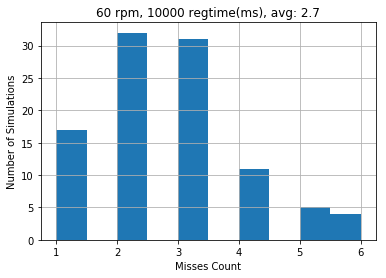

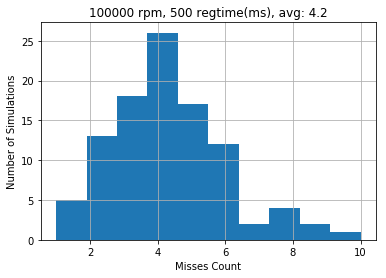

In [10]:
def request_is_miss(timestamp,age,ttl):
    if timestamp>0 and age>=timestamp:
        return False
    p=get_expiration_probability(age,ttl)
    if p > random.random():
        return True
    return False

def simulate_count_misses(rpm,regeneration_time):
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    misses=0
    timestamp=0
    for k in age:
        if request_is_miss(timestamp,k,200000):
            misses+=1
            if timestamp==0:
                timestamp=k+regeneration_time
                
    return misses
        
def print_misses_count_simulation_histogram(rpm,regeneration_time):
    vals=[]
    for i in range(0,100):
        vals.append(simulate_count_misses(rpm,regeneration_time))

    avg=np.average(vals)    
    plt.hist(vals)
    plt.xlabel('Misses Count')
    plt.ylabel('Number of Simulations')
    plt.title('%d rpm, %d regtime(ms), avg: %.1f' %(rpm,regeneration_time,avg))
    plt.grid(True)
    plt.show()
    
print_misses_count_simulation_histogram(60,10000)
print_misses_count_simulation_histogram(100000,500)

# Grafico de efectividad
El objetivo es lograr que la cantidad de regeneraciones sea minima, y sobre todo minimizar la probabilidad de que se este reconstruyendo la misma clave de forma concurrente.   
Se puede ver ese valor tambien como minimizar la cantidad total de miss para cada throughput y cada tiempo de regeneracion.  
Los siguientes graficos muestran la cantidad total de miss obtenidos segun el throughput y para distintos tiempos de regeneracion de la clave.


In [54]:
def probability_some_miss_by_time_exppfunc(rpm,expp):
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    acc=[None]*250000
    none=1
    for k in age:
        p=expp(k,200000)
        q=1-p
        none=none*q
        acc[int(round(k))]=(1-none)
        
    prev=0
    for idx, val in enumerate(acc):
        if val is None:
            acc[idx]=prev
        else:
            prev=acc[idx]
    return acc

def get_miss_count_by_rpm_with_regeneration(rpm,regeneration_time,expp):
    miss_prob=probability_some_miss_by_time_exppfunc(rpm,expp)
    age=np.arange(0., 250000., get_millis_between_requests(rpm))
    accum=0
    for k in age:
        p=expp(k,200000)
        psomeprevmiss=miss_prob[int(round(k-regeneration_time))]
        pefectivemiss=p* (1-psomeprevmiss)
        accum=accum+pefectivemiss
    return(accum)

def plot_efectivity_by_regtime(regeneration_time,expp):
    rpms=[2**x for x in range(1,17)]
    rpms[15]=60000
    mcnt=[get_miss_count_by_rpm_with_regeneration(r,regeneration_time,expp) for r in rpms]
    idxs=[ idx for idx,x in enumerate(rpms)]
    
    maxval=np.max(mcnt)
    plt.figure(figsize=(15,4))
    plt.bar(idxs, mcnt)
    plt.xticks(idxs, rpms)
    plt.title("%d regeneration_time(ms)  MAX:%0.2f" % (regeneration_time,maxval))
    plt.xlabel('Throughput (rpm)')
    plt.ylabel('Number of total Misses')
    plt.show()
    
def plot_expiration_probability_function(expp,title):
    age=np.arange(0., 250000., 1)
    proba=[expp(x,200000) for x in age]
    age=[x/1000 for x in age]
    plt.plot(age,proba)
    plt.axis([0, 250, -0.1, 1.1])
    plt.xlabel('Time (s)')
    plt.ylabel('Expiration Probability')
    plt.title(title)
    plt.show()
    
def plot_efectivity_using_expiration_probability_function(expp):
    plot_efectivity_by_regtime(1000,expp) 
    #plot_efectivity_by_regtime(500,expp)
    #plot_efectivity_by_regtime(2000,expp)
    #plot_efectivity_by_regtime(10000,expp)
    #plot_efectivity_by_regtime(20000,expp)
    


# Linear Probability

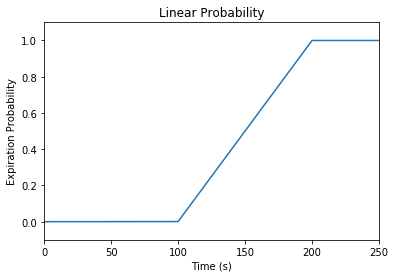

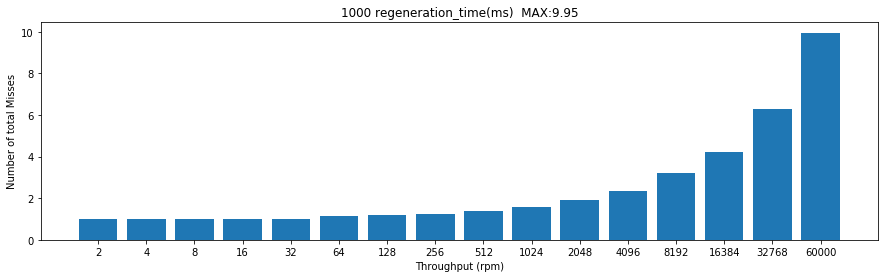

In [55]:
def get_expiration_probability_linear(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return invzone

plot_expiration_probability_function(get_expiration_probability_linear,"Probabilidad Lineal")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_linear)

# Situacion trivial

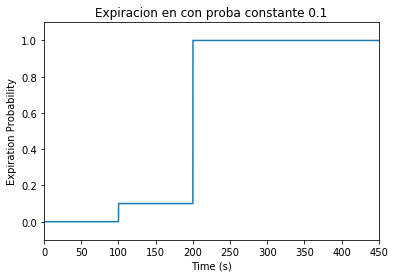

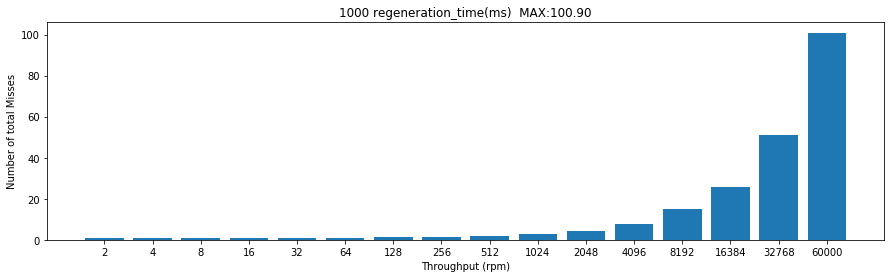

In [52]:
def get_expiration_probability_linear(age,ttl):
    if age>200000:
        return 1
    if age>100000:
        return 0.1
    
    return 0

plot_expiration_probability_function(get_expiration_probability_linear,"Expiracion en con proba constante 0.1")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_linear)

# Exponencial simple
$$
\left(e^{x\cdot \:1}-1\right)/\left(e^1-1\right)
$$

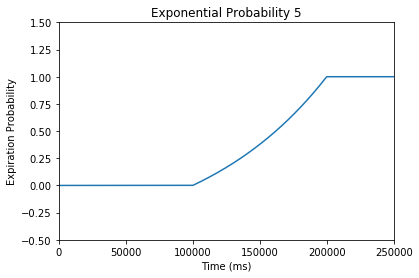

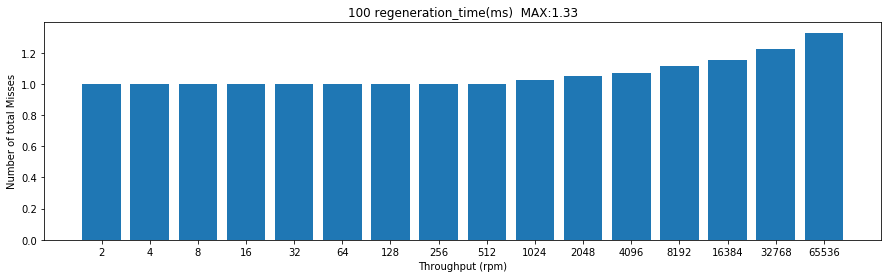

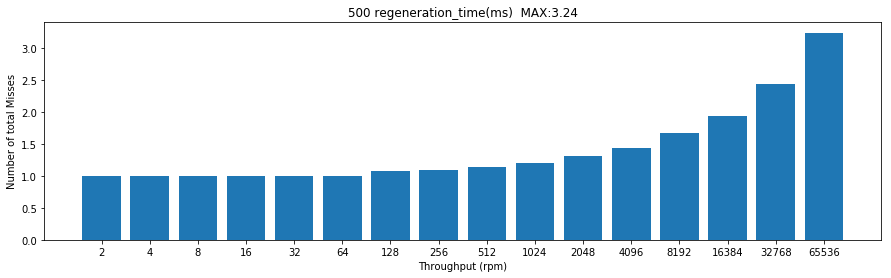

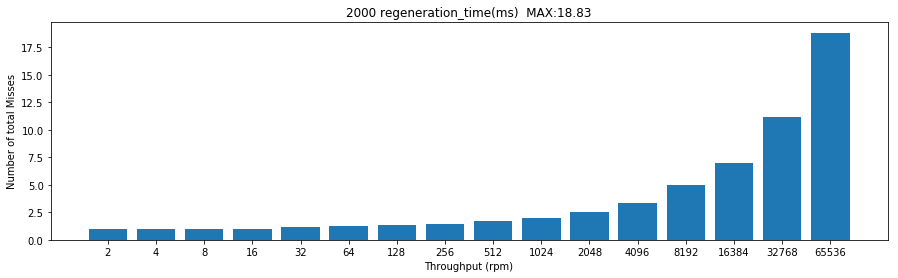

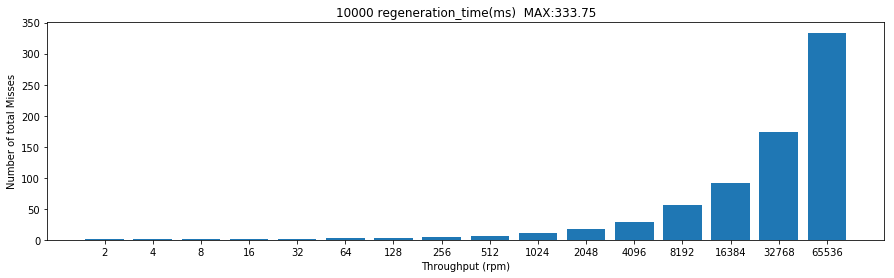

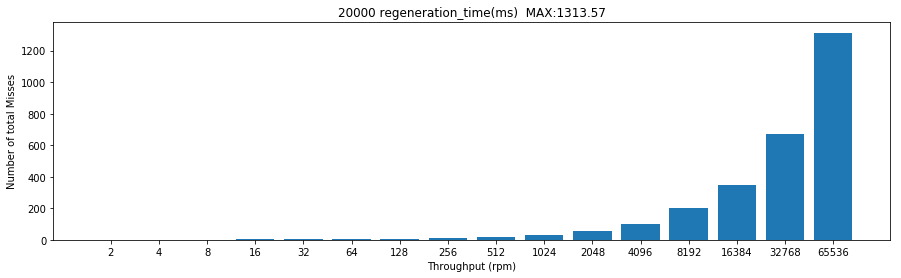

In [12]:
def get_expiration_probability_exp(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return (math.exp(invzone*1.0)-1)/(math.exp(1)-1.0)
    

plot_expiration_probability_function(get_expiration_probability_exp,"Exponential Probability 5")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_exp)

# Exponencial 5
$$
\left(e^{x\cdot \:5}-1\right)/\left(e^5-1\right)
$$

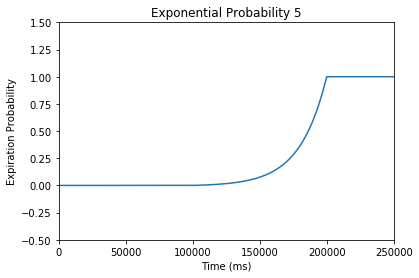

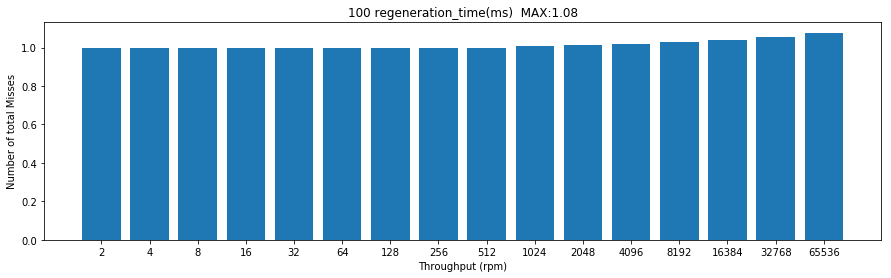

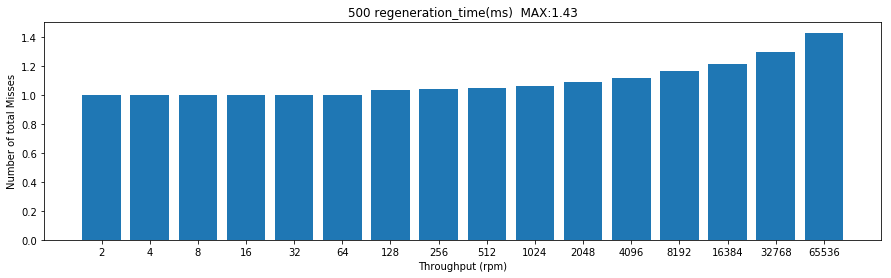

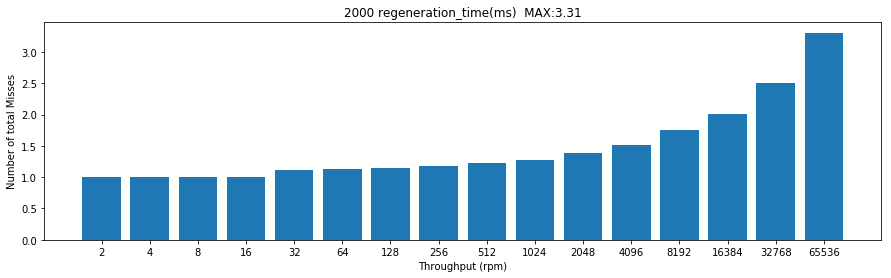

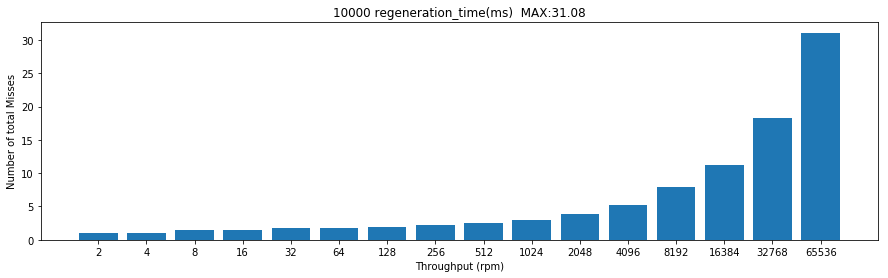

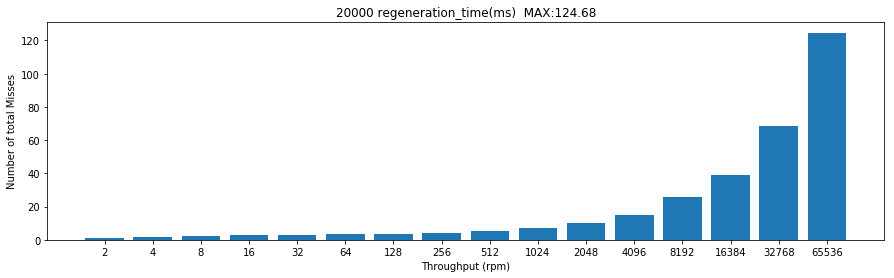

In [13]:
def get_expiration_probability_exp(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return (math.exp(invzone*5.0)-1)/(math.exp(5)-1.0)
    

plot_expiration_probability_function(get_expiration_probability_exp,"Exponential Probability 5")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_exp)

# Exponencial 11
$$
\left(e^{x\cdot \:11}-1\right)/\left(e^{11}-1\right)
$$

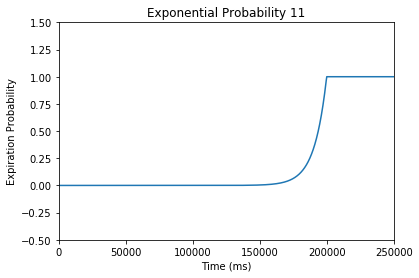

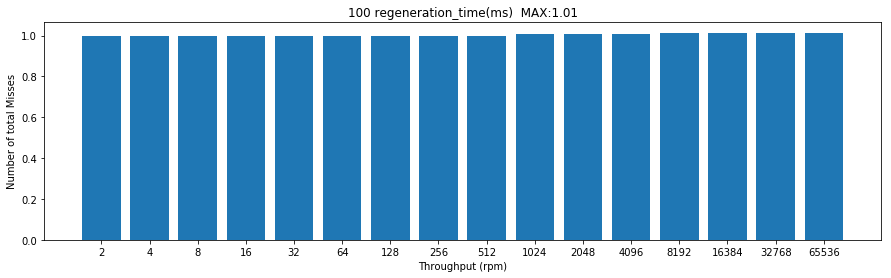

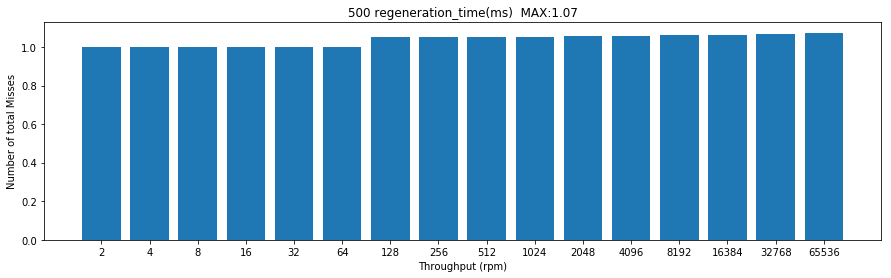

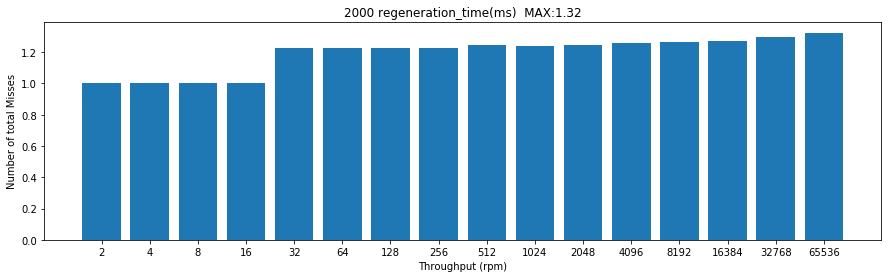

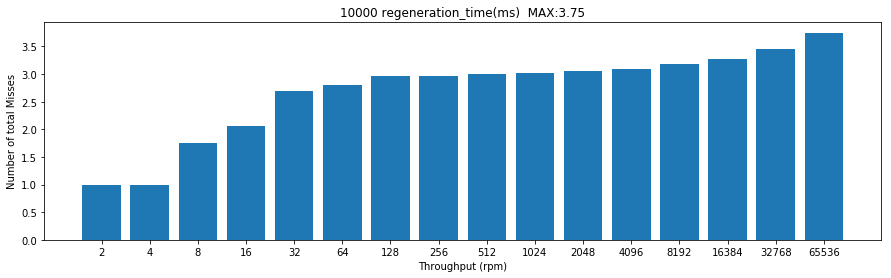

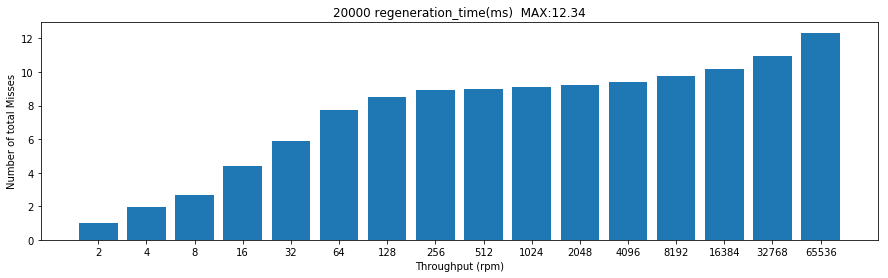

In [14]:
def get_expiration_probability_exp11(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return (math.exp(invzone*11.0)-1)/(math.exp(11)-1.0)
    

plot_expiration_probability_function(get_expiration_probability_exp11,"Exponential Probability 11")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_exp11)

# Potencia 1/4
$$
\left(x\right)^{\frac{1}{4}}
$$

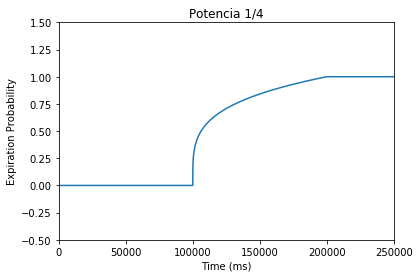

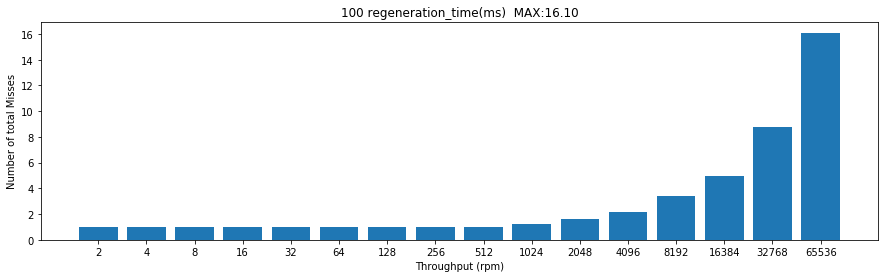

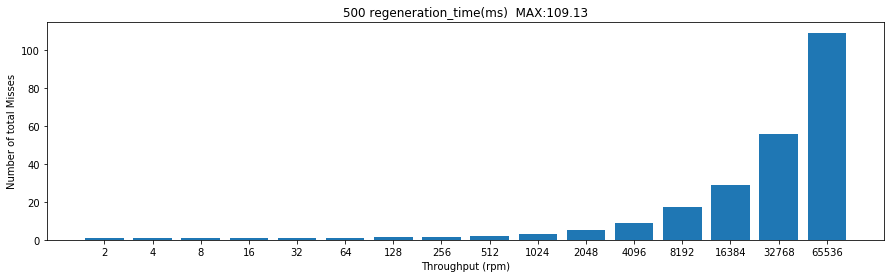

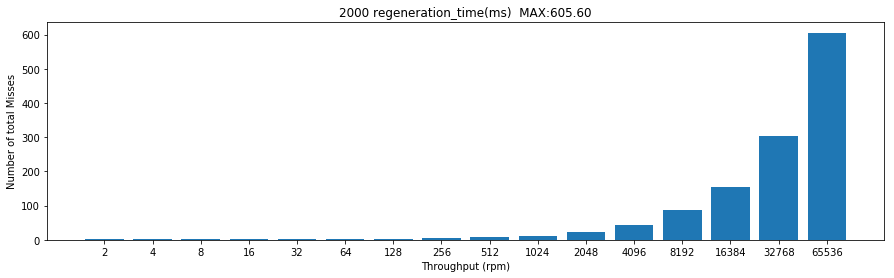

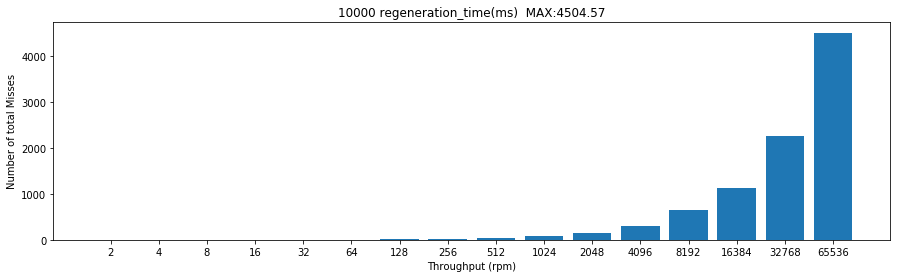

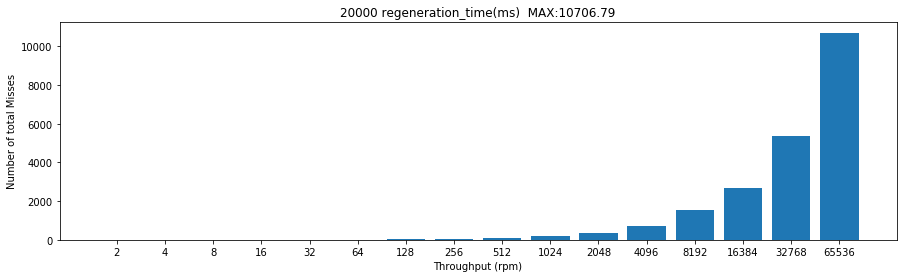

In [15]:
def get_expiration_probability_pot14(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return invzone**0.25
    

plot_expiration_probability_function(get_expiration_probability_pot14,"Potencia 1/4")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_pot14)

# Potencia 4
$$
\left(x\right)^{4}
$$

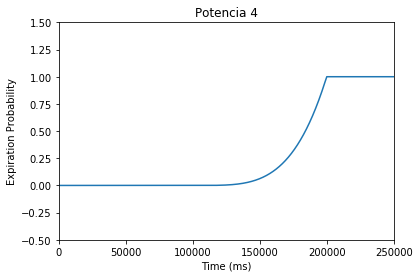

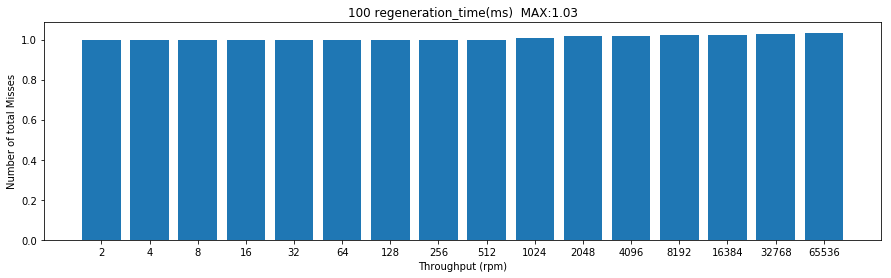

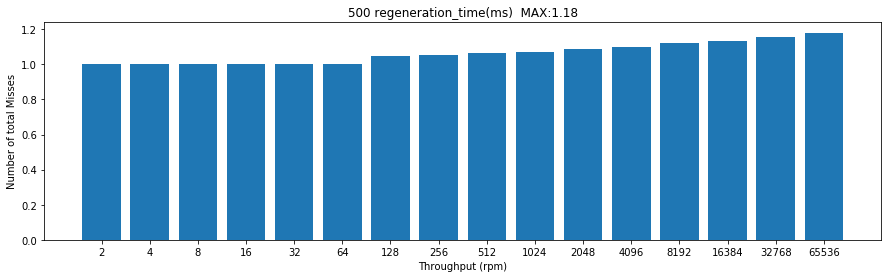

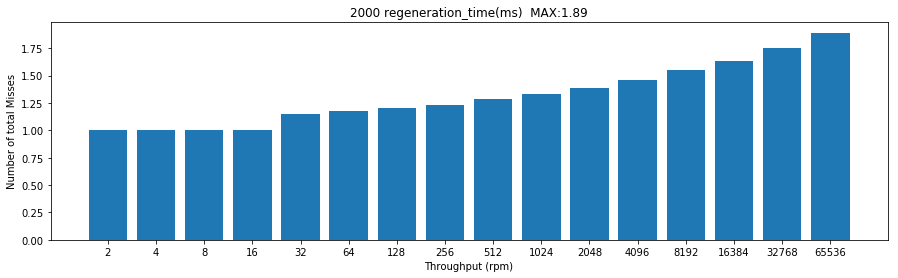

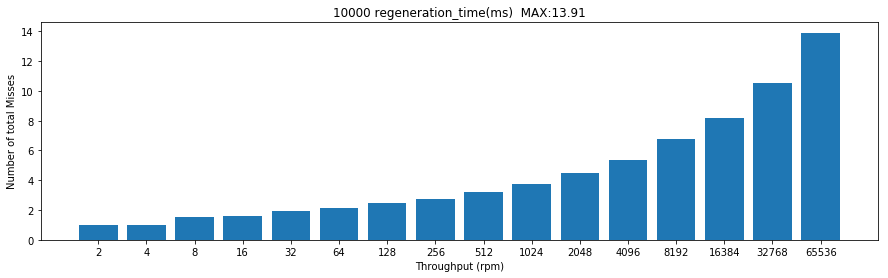

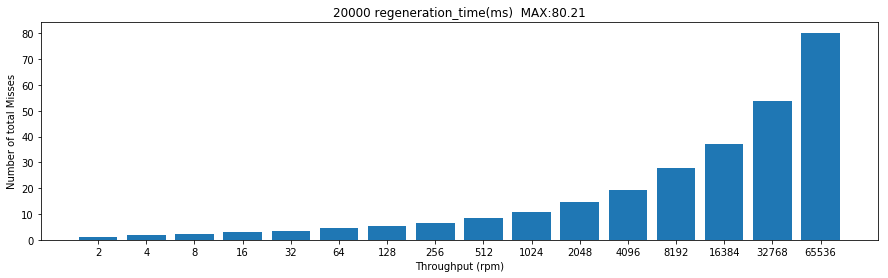

In [16]:
def get_expiration_probability_pot4(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return invzone**4
    

plot_expiration_probability_function(get_expiration_probability_pot4,"Potencia 4")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_pot4)

# Potencia 8
$$
\left(x\right)^{8}
$$

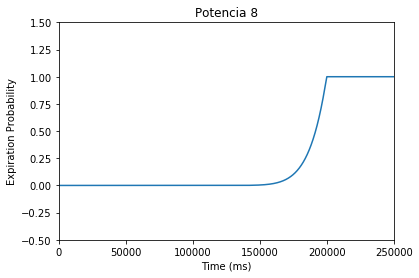

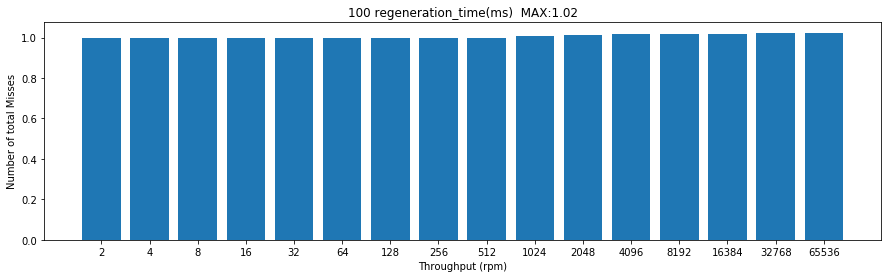

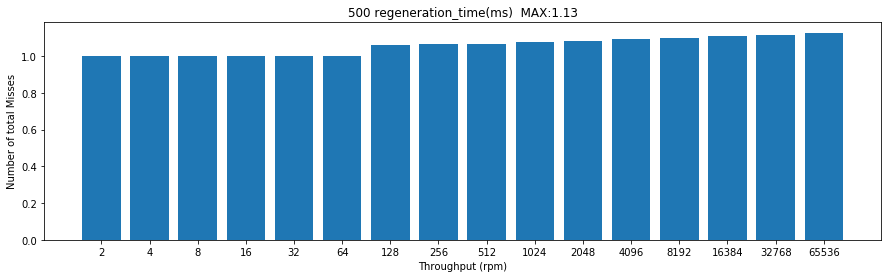

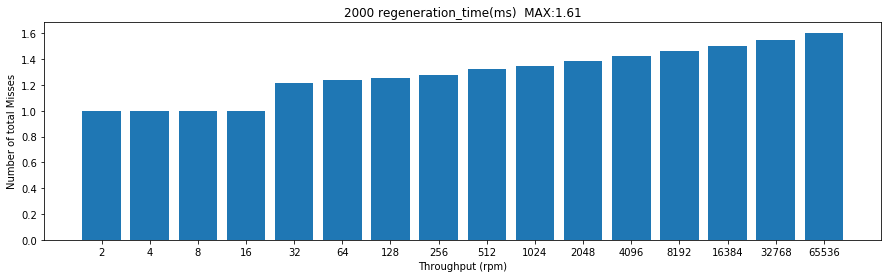

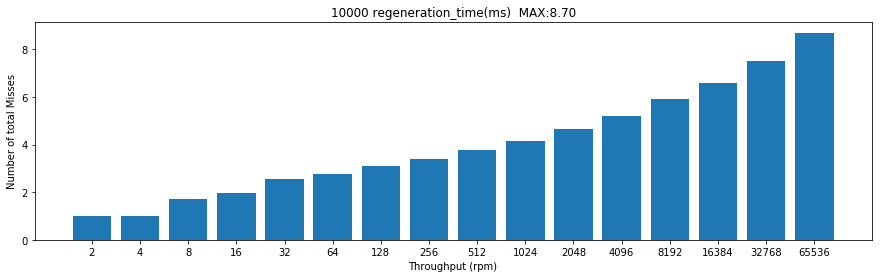

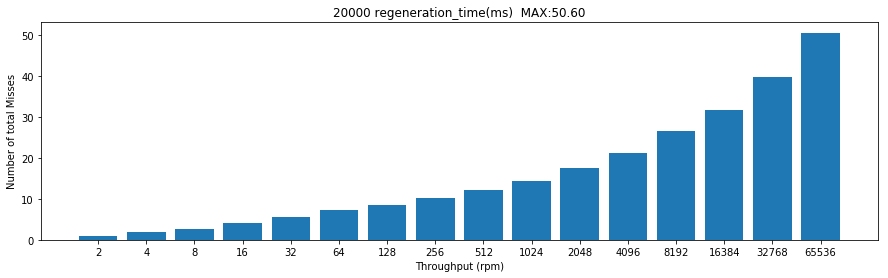

In [17]:
def get_expiration_probability_pot8(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return invzone**8
    

plot_expiration_probability_function(get_expiration_probability_pot8,"Potencia 8")
plot_efectivity_using_expiration_probability_function(get_expiration_probability_pot8)

# Conclusion.
Se encuentra que la mejor performance se dá con una exponencial potencia 11.  
$$
\left(e^{x\cdot \:11}-1\right)/\left(e^{11}-1\right)
$$
El valor 11 se encontro por prueba.  
Era totalmente esperable que esa forma de la curva tuviera la mejor performance.   








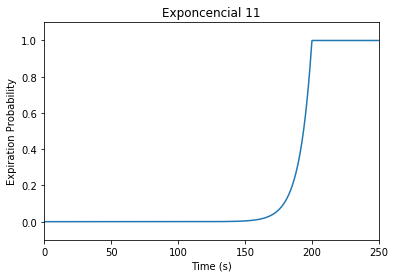

In [59]:
plot_expiration_probability_function(get_expiration_probability_exp11,"Exponcencial 11")

# Simulación
Se deja a continuacion una simulacion para evaluar el comportamiento contra la mejor funcion encontrada segun parametros arbitrarios

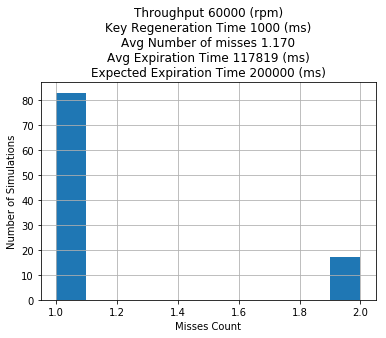

In [57]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import random
import math

def get_expiration_probability_exp11(age,ttl):
    z=ttl/2
    invzone=(age-z)/z
    if invzone<0:
        return 0
    if invzone>=1:
        return 1
    return (math.exp(invzone*11.0)-1)/(math.exp(11)-1.0)

def request_is_miss(timestamp,age,ttl):
    if timestamp>0 and age>=timestamp:
        return False
    p=get_expiration_probability_exp11(age,ttl)
    if p > random.random():
        return True
    return False

def simulate_count_misses(throughput_rpm,regeneration_time,ttl):
    age=np.arange(0., ttl*1.5, 60000/throughput_rpm)
    misses=0
    timestamp=0
    for k in age:
        if request_is_miss(timestamp,k,ttl):
            misses+=1
            if timestamp==0:
                timestamp=k+regeneration_time
                
    return misses,(timestamp-regeneration_time)
        
def print_misses_count_simulation_histogram(rpm,regeneration_time,ttl,steps):
    count_misses=[]
    key_ttls=[]
    for i in range(0,steps):
        mcnt,kttl=simulate_count_misses(rpm,regeneration_time,ttl)
        count_misses.append(mcnt)
        key_ttls.append(kttl)

    avg=np.average(count_misses)    
    avgttl=np.average(key_ttls)    
    plt.hist(count_misses)
    plt.xlabel('Misses Count')
    plt.ylabel('Number of Simulations')
    plt.title('Throughput %d (rpm)\n'
              'Key Regeneration Time %d (ms)\n'
              'Avg Number of misses %.3f\n'
              'Avg Expiration Time %d (ms)\n'
              'Expected Expiration Time %d (ms)' %(rpm,regeneration_time,avg,avgttl,ttl))
    plt.grid(True)
    plt.show()
    
    
# Correr una simulacion rapida o lenta(mas precisa)    
do_fast_simulation=False

# Throughput en request por minuto
throughput_rpm=60000 # 100 krpm

# Tiempo en milisegundos que demora regenerar una key que dio miss
key_regeneration_time_mills=1000  # 1 segundo

# Tiempo de vida maximo de una key en el cache en milisegundos
cache_expiration_time_mills=200*1000 # 5 minutos

print_misses_count_simulation_histogram(throughput_rpm,key_regeneration_time_mills,cache_expiration_time_mills,10 if do_fast_simulation else 100)